In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
  df = pd.read_csv("/content/Social_Network_Ads (1).csv")

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
round(df.describe(),1)

,User ID,Age,EstimatedSalary,Purchased
count,400.0,400.0,400.0,400.0
mean,15691539.8,37.7,69742.5,0.4
std,71658.3,10.5,34097.0,0.5
min,15566689.0,18.0,15000.0,0.0
25%,15626763.8,29.8,43000.0,0.0
50%,15694341.5,37.0,70000.0,0.0
75%,15750363.0,46.0,88000.0,1.0
max,15815236.0,60.0,150000.0,1.0


In [ ]:
df = df.iloc[:, 2:]

In [ ]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(df.drop("Purchased",axis =1),
                                                 df["Purchased"],test_size=0.3,random_state=0)

In [ ]:
X_train.shape,X_test.shape

((280, 2), (120, 2))

In [ ]:
X_train.head()

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000


In [ ]:
X_test.head()

,Age,EstimatedSalary
132,30,87000
309,38,50000
341,35,75000
196,30,79000
246,35,50000


In [ ]:
Scaler = MinMaxScaler()
Scaler.fit(X_train)

MinMaxScaler()

In [ ]:
X_train_scaled = Scaler.transform(X_train)
X_test_scaled  = Scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [ ]:
X_train_scaled.head()

,Age,EstimatedSalary
0,0.190476,0.000000
1,1.000000,0.644444
2,0.476190,0.718519
3,0.523810,0.681481
4,0.571429,0.281481


In [ ]:
X_test_scaled.head()

,Age,EstimatedSalary
0,0.285714,0.533333
1,0.476190,0.259259
2,0.404762,0.444444
3,0.285714,0.474074
4,0.404762,0.259259


In [ ]:
round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.5,0.4
std,0.2,0.3
min,0.0,0.0
25%,0.3,0.2
50%,0.5,0.4
75%,0.7,0.5
max,1.0,1.0


In [ ]:
round(X_test_scaled.describe(),1)

,Age,EstimatedSalary
count,120.0,120.0
mean,0.5,0.4
std,0.3,0.2
min,0.0,0.0
25%,0.2,0.2
50%,0.4,0.4
75%,0.6,0.5
max,1.0,1.0


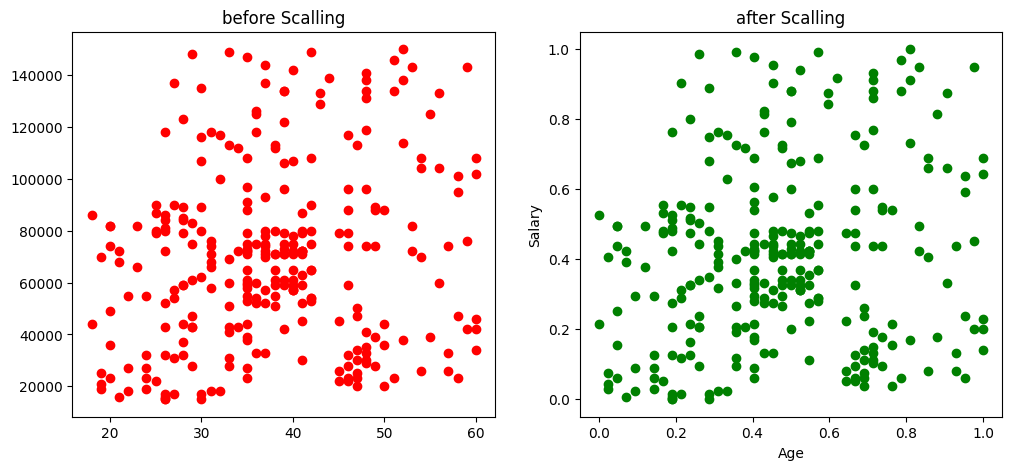

In [ ]:
# Effect of Scaling

fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize = (12,5))
ax1.scatter(X_train["Age"],X_train["EstimatedSalary"],color = "red")
plt.xlabel("Age")
plt.ylabel("Salary")
ax1.set_title("before Scalling")
ax2.scatter(X_train_scaled["Age"],X_train_scaled["EstimatedSalary"],color = "g")
plt.xlabel("Age")
plt.ylabel("Salary")
ax2.set_title("after Scalling")
plt.show()

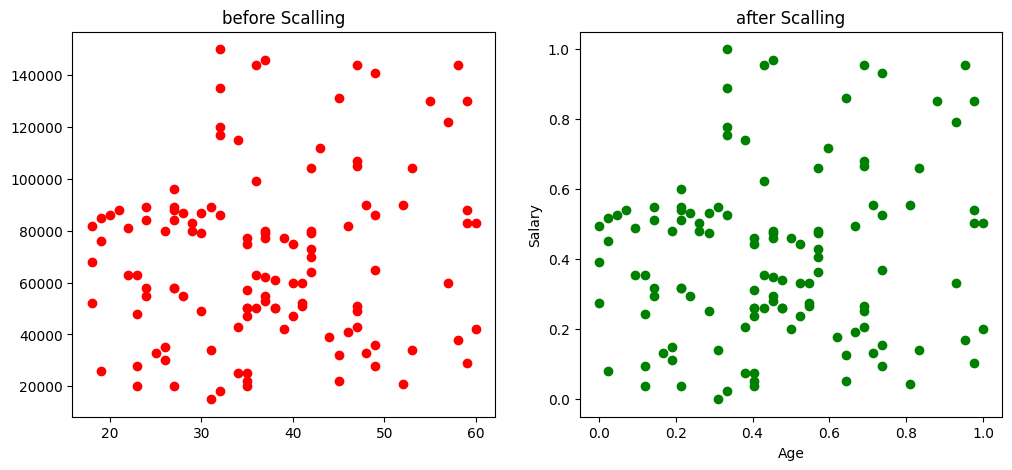

In [ ]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize = (12,5))
ax1.scatter(X_test["Age"],X_test["EstimatedSalary"],color = "red")
plt.xlabel("Age")
plt.ylabel("Salary")
ax1.set_title("before Scalling")
ax2.scatter(X_test_scaled["Age"],X_test_scaled["EstimatedSalary"],color = "g")
plt.xlabel("Age")
plt.ylabel("Salary")
ax2.set_title("after Scalling")
plt.show()

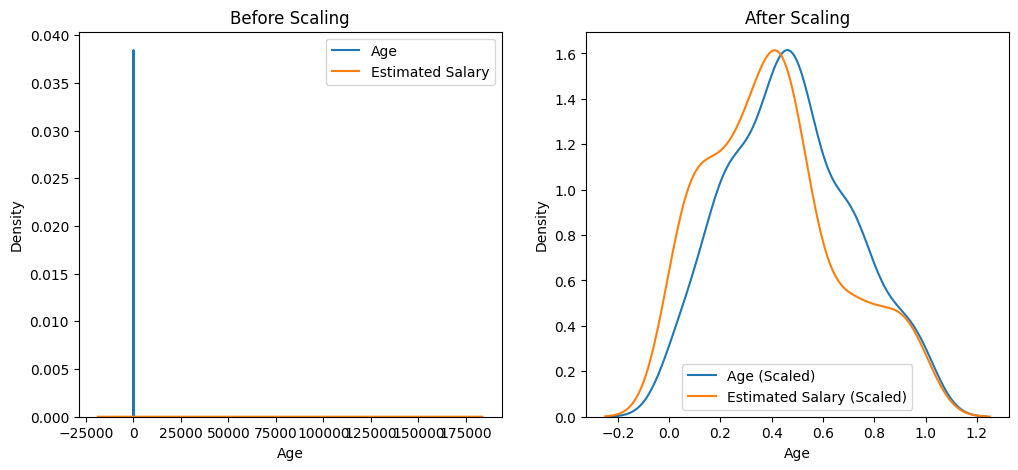

In [ ]:
 fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Age"], ax=ax1, label="Age")
sns.kdeplot(X_train["EstimatedSalary"], ax=ax1, label="Estimated Salary")
ax1.legend()

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Age"], ax=ax2, label="Age (Scaled)")
sns.kdeplot(X_train_scaled["EstimatedSalary"], ax=ax2, label="Estimated Salary (Scaled)")
ax2.legend()

plt.show()


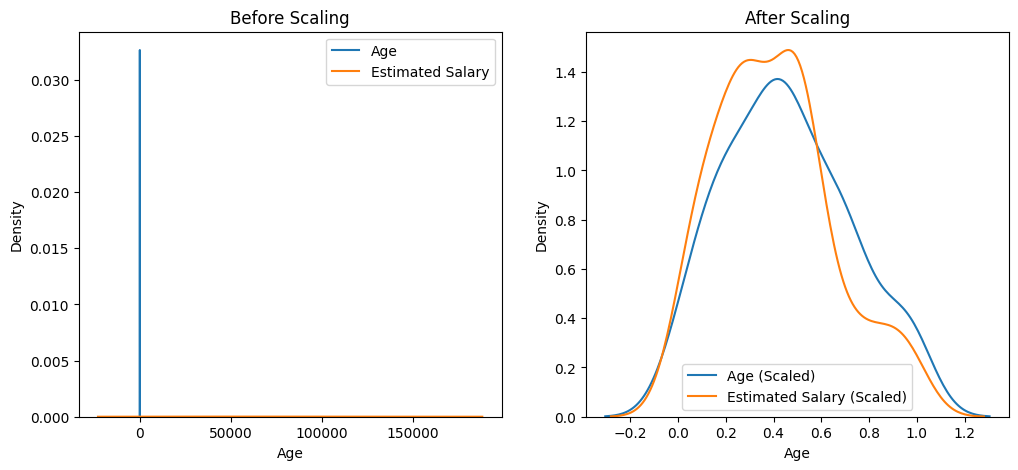

In [ ]:
 fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_test["Age"], ax=ax1, label="Age")
sns.kdeplot(X_test["EstimatedSalary"], ax=ax1, label="Estimated Salary")
ax1.legend()

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_test_scaled["Age"], ax=ax2, label="Age (Scaled)")
sns.kdeplot(X_test_scaled["EstimatedSalary"], ax=ax2, label="Estimated Salary (Scaled)")
ax2.legend()

plt.show()

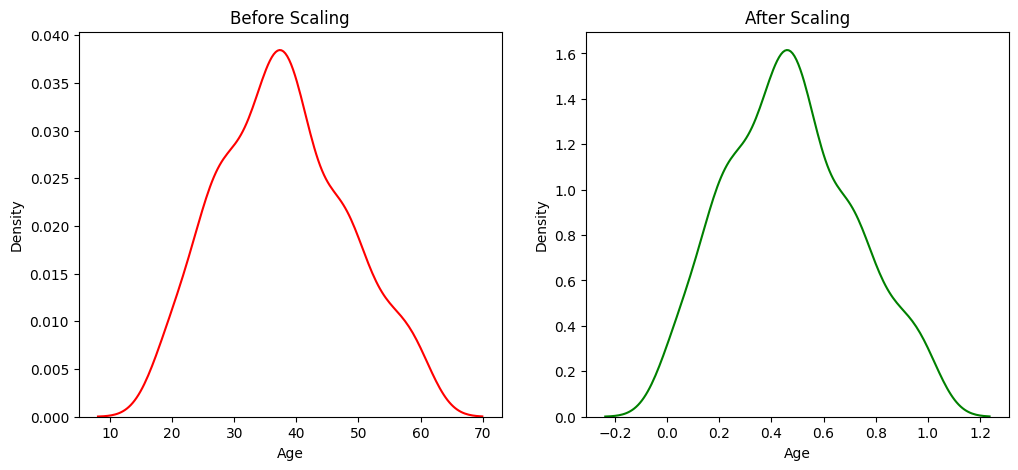

In [ ]:
# comprision of distribution
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Age"],ax = ax1,color="r")
# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Age"],ax = ax2,color="g")
plt.show()

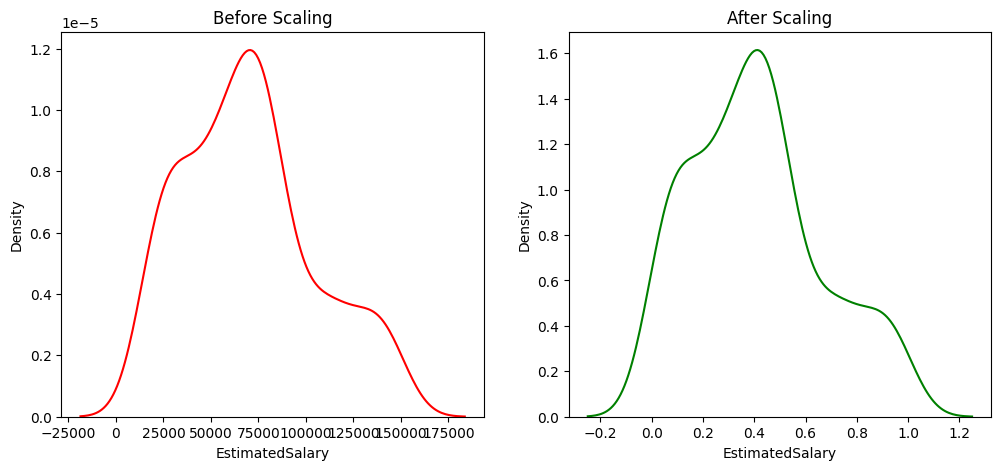

In [ ]:
# comprision of distribution
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["EstimatedSalary"],ax = ax1,color="r")
# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["EstimatedSalary"],ax = ax2,color="g")
plt.show()

In [ ]:
# Logistic_model

log = LogisticRegression()
log_scaled = LogisticRegression()

In [ ]:
log.fit(X_train,y_train)
log_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [ ]:
y_pred = log.predict(X_test)
Y_pred_scaled = log_scaled.predict(X_test_scaled)


In [ ]:
print("Accuracy_score before scaling",accuracy_score(y_test, y_pred))
print("Accuracy_score After Scaling",accuracy_score(y_test, Y_pred_scaled))

Accuracy_score before scaling 0.875
Accuracy_score After Scaling 0.8416666666666667


In [ ]:
# DECIGiON TREE

dt = DecisionTreeClassifier()
dt_Scaled = DecisionTreeClassifier()

In [ ]:
dt.fit(X_train,y_train)
dt_Scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [ ]:
y_preddt = dt.predict(X_test)
y_preddt_scaled = dt_Scaled.predict(X_test_scaled)

In [ ]:
print("Actual accuracy score before scaling",accuracy_score(y_test,y_preddt))
print("scaled accuracy score after scaling ",accuracy_score(y_test,y_preddt_scaled))

Actual accuracy score before scaling 0.875
scaled accuracy score after scaling  0.8666666666666667


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model_scaled = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
model.fit(X_train,y_train)
model_scaled.fit(X_train_scaled,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_predRF = model.predict(X_test)
y_predRF_scaled = model_scaled.predict(X_test_scaled )

In [ ]:
print("Actual Accoracy before scaling",accuracy_score(y_test,y_predRF))
print("scaled Accuracy after scaling ",accuracy_score(y_test,y_predRF_scaled))

Actual Accoracy before scaling 0.9166666666666666
scaled Accuracy after scaling  0.9166666666666666


In [ ]:
knnmodel = KNeighborsClassifier(n_neighbors=5)
knnmodel_scaled = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knnmodel.fit(X_train,y_train)
knnmodel_scaled.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
y_predknn = knnmodel.predict(X_test)
y_predknn_scaled = knnmodel_scaled.predict(X_test_scaled)

In [ ]:
print("Actual Accoracy before scaling",accuracy_score(y_test,y_predknn))
print("scaled Accuracy after scaling ",accuracy_score(y_test,y_predknn_scaled))

Actual Accoracy before scaling 0.825
scaled Accuracy after scaling  0.9166666666666666


In [ ]:
SVM1 = SVC()
SVM1_scaled = SVC()

In [ ]:
SVM1.fit(X_train,y_train)
SVM1_scaled.fit(X_train_scaled,y_train)

SVC()

In [ ]:
y_predSVM = SVM1.predict(X_test)
y_predSVM_scaled = SVM1_scaled.predict(X_test_scaled)

In [ ]:
print("Actual Accoracy before scaling",accuracy_score(y_test,y_predSVM))
print("scaled Accuracy after scaling ",accuracy_score(y_test,y_predSVM_scaled))

Actual Accoracy before scaling 0.7916666666666666
scaled Accuracy after scaling  0.9083333333333333


In [ ]:
# With Outlier

In [ ]:
df = pd.concat(
    [
        df,
        pd.DataFrame({
            "Age": [5, 80, 90],
            "EstimatedSalary": [1000, 30000, 70000],
            "Purchased": [0, 1, 1]
        })
    ],
    ignore_index=True
)


In [ ]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


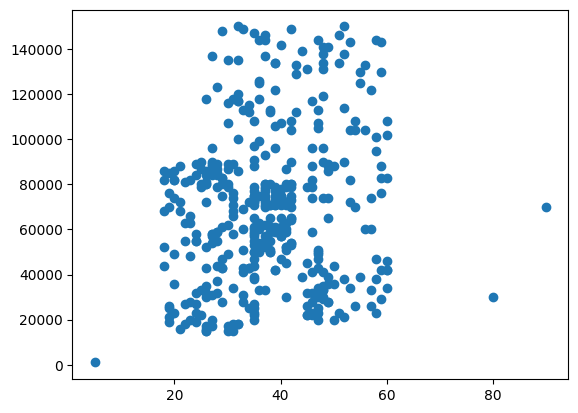

In [ ]:
plt.scatter(df["Age"],df["EstimatedSalary"])

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(df.drop("Purchased",axis =1),
                                                 df["Purchased"],test_size=0.3,random_state=0)

In [ ]:
X_train.shape,X_test.shape

((282, 2), (121, 2))

In [ ]:
Scaler = MinMaxScaler()
Scaler.fit(X_train)

MinMaxScaler()

In [ ]:
X_train_scaled = Scaler.transform(X_train)
X_test_scaled  = Scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

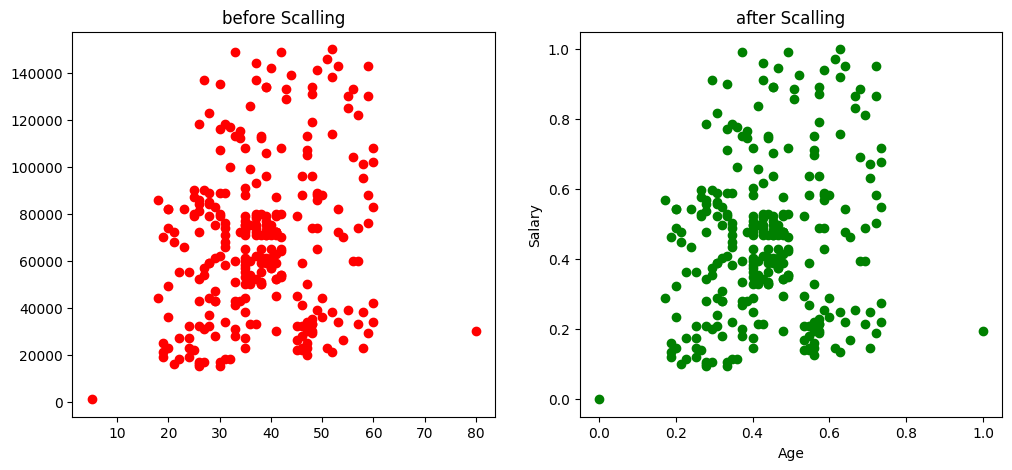

In [ ]:
# Effect of Scaling

fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize = (12,5))
ax1.scatter(X_train["Age"],X_train["EstimatedSalary"],color = "red")
plt.xlabel("Age")
plt.ylabel("Salary")
ax1.set_title("before Scalling")
ax2.scatter(X_train_scaled["Age"],X_train_scaled["EstimatedSalary"],color = "g")
plt.xlabel("Age")
plt.ylabel("Salary")
ax2.set_title("after Scalling")
plt.show()

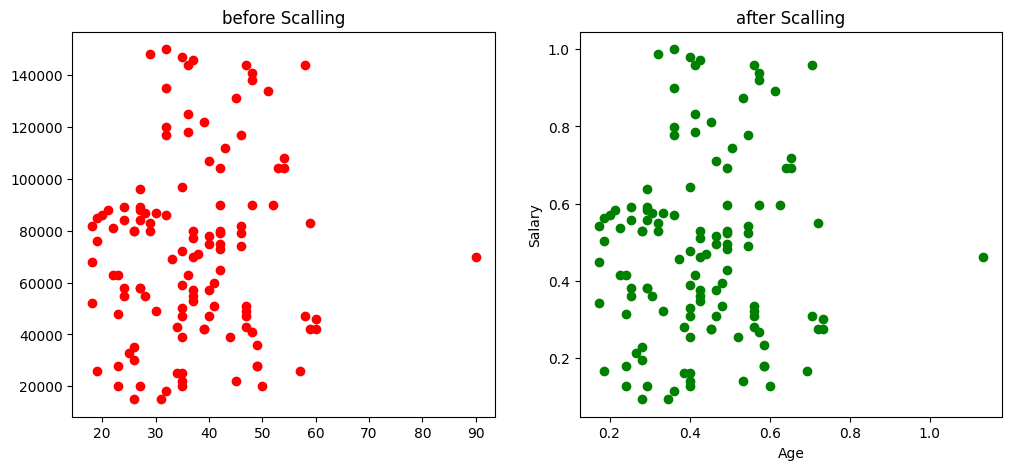

In [ ]:

fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize = (12,5))
ax1.scatter(X_test["Age"],X_test["EstimatedSalary"],color = "red")
plt.xlabel("Age")
plt.ylabel("Salary")
ax1.set_title("before Scalling")
ax2.scatter(X_test_scaled["Age"],X_test_scaled["EstimatedSalary"],color = "g")
plt.xlabel("Age")
plt.ylabel("Salary")
ax2.set_title("after Scalling")
plt.show()

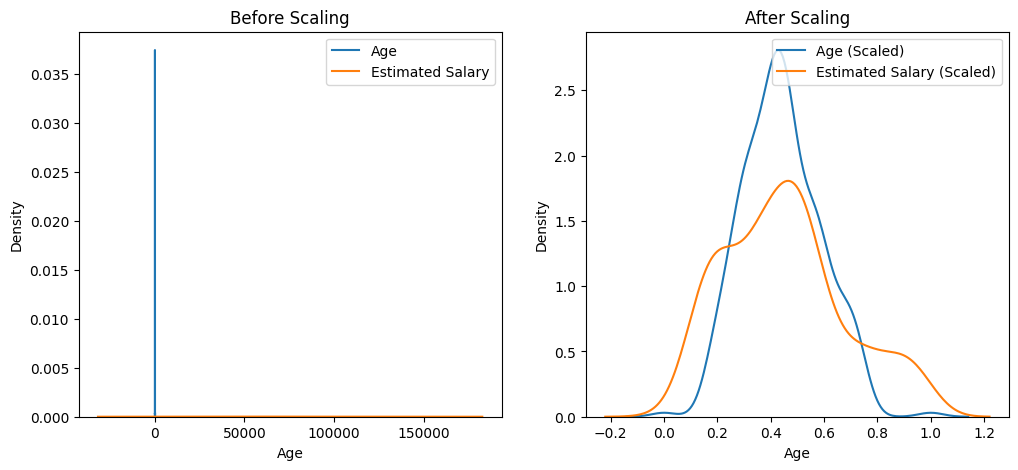

In [ ]:
 fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Age"], ax=ax1, label="Age")
sns.kdeplot(X_train["EstimatedSalary"], ax=ax1, label="Estimated Salary")
ax1.legend()

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Age"], ax=ax2, label="Age (Scaled)")
sns.kdeplot(X_train_scaled["EstimatedSalary"], ax=ax2, label="Estimated Salary (Scaled)")
ax2.legend()

plt.show()

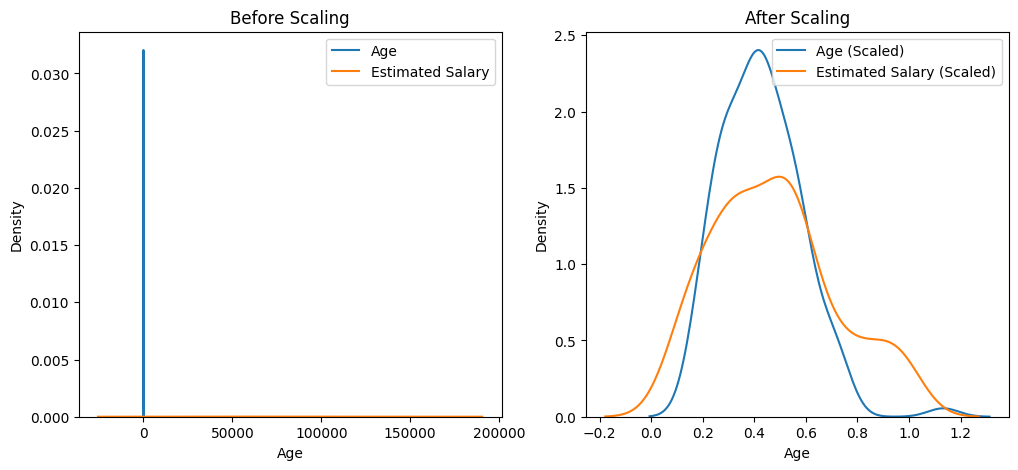

In [ ]:
 fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_test["Age"], ax=ax1, label="Age")
sns.kdeplot(X_test["EstimatedSalary"], ax=ax1, label="Estimated Salary")
ax1.legend()

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_test_scaled["Age"], ax=ax2, label="Age (Scaled)")
sns.kdeplot(X_test_scaled["EstimatedSalary"], ax=ax2, label="Estimated Salary (Scaled)")
ax2.legend()

plt.show()

In [ ]:
# Logistic_model

log = LogisticRegression()
log_scaled = LogisticRegression()

In [ ]:
log.fit(X_train,y_train)
log_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [ ]:
y_pred = log.predict(X_test)
Y_pred_scaled = log_scaled.predict(X_test_scaled)

In [ ]:
print("Accuracy_score before scaling",accuracy_score(y_test, y_pred))
print("Accuracy_score After Scaling",accuracy_score(y_test, Y_pred_scaled))

Accuracy_score before scaling 0.859504132231405
Accuracy_score After Scaling 0.7933884297520661


In [ ]:

dt = DecisionTreeClassifier()
dt_Scaled = DecisionTreeClassifier()

In [ ]:
dt.fit(X_train,y_train)
dt_Scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [ ]:
y_preddt = dt.predict(X_test)
y_preddt_scaled = dt_Scaled.predict(X_test_scaled)

In [ ]:
print("Actual accuracy score before scaling",accuracy_score(y_test,y_preddt))
print("scaled accuracy score after scaling ",accuracy_score(y_test,y_preddt_scaled))

Actual accuracy score before scaling 0.8760330578512396
scaled accuracy score after scaling  0.8677685950413223


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model_scaled = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
model.fit(X_train,y_train)
model_scaled.fit(X_train_scaled,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_predRF = model.predict(X_test)
y_predRF_scaled = model_scaled.predict(X_test_scaled )

In [ ]:
print("Actual accuracy score before scaling",accuracy_score(y_test,y_predRF))
print("scaled accuracy score after scaling ",accuracy_score(y_test,y_predRF_scaled))

Actual accuracy score before scaling 0.8925619834710744
scaled accuracy score after scaling  0.8925619834710744


In [ ]:
knnmodel = KNeighborsClassifier(n_neighbors=5)
knnmodel_scaled = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knnmodel.fit(X_train,y_train)
knnmodel_scaled.fit(X_train_scaled,y_train)


KNeighborsClassifier()

In [ ]:
y_predknn = knnmodel.predict(X_test)
y_predknn_scaled = knnmodel_scaled.predict(X_test_scaled)

In [ ]:
print("Actual Accoracy before scaling",accuracy_score(y_test,y_predknn))
print("scaled Accuracy after scaling ",accuracy_score(y_test,y_predknn_scaled))

Actual Accoracy before scaling 0.7933884297520661
scaled Accuracy after scaling  0.8677685950413223


In [ ]:
SVM1 = SVC()
SVM1_scaled = SVC()

In [ ]:
SVM1.fit(X_train,y_train)
SVM1_scaled.fit(X_train_scaled,y_train)

SVC()

In [ ]:
y_predSVM = SVM1.predict(X_test)
y_predSVM_scaled = SVM1_scaled.predict(X_test_scaled)

In [ ]:
print("Actual Accoracy before scaling",accuracy_score(y_test,y_predSVM))
print("scaled Accuracy after scaling ",accuracy_score(y_test,y_predSVM_scaled))

Actual Accoracy before scaling 0.7933884297520661
scaled Accuracy after scaling  0.8925619834710744
